This notebook is designed to perform a bivariate CTW to predict meteorological features.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Preprocessing

In [13]:
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

time_to_keep = ["year", "month", "day"]     # "year", "month", "day", "hour"

# Keep relevant columns and rows
df = df[time_to_keep + ["pm2.5", "TEMP"]]
df = df.rename(columns = {"pm2.5" : "Particule", "TEMP" : "Temp"})

# Sort to create the features and drop temporal columns
df = df.sort_values(by = time_to_keep, ascending = True)
df["Previous_Temp"] = df["Temp"].shift(1)
df["Previous_Particule"] = df["Particule"].shift(1)
df = df.drop(time_to_keep + ["Temp"], axis = 1).dropna()
df = df.reset_index(drop = True)

Data vizualisation

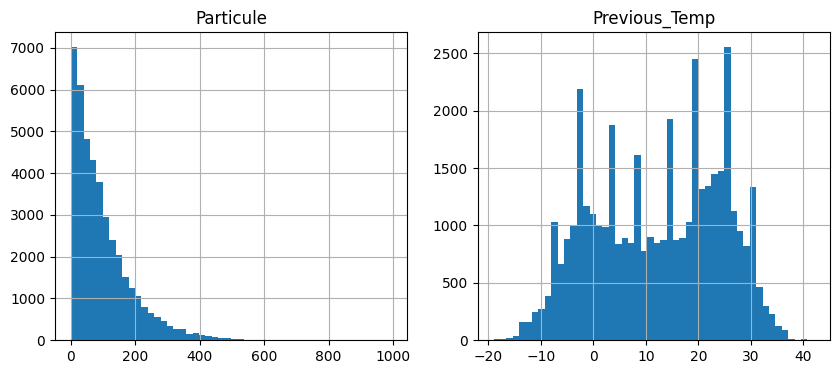

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["Particule"].hist(bins=50, ax=axes[0])
axes[0].set_title("Particule")

df["Previous_Temp"].hist(bins=50, ax=axes[1])
axes[1].set_title("Previous_Temp");

The particule distribution is heavy tailed and looks gamma / exponential. Anyway, we can log it to make it normal. Then, we can normalize both distribution with the standard scaling.

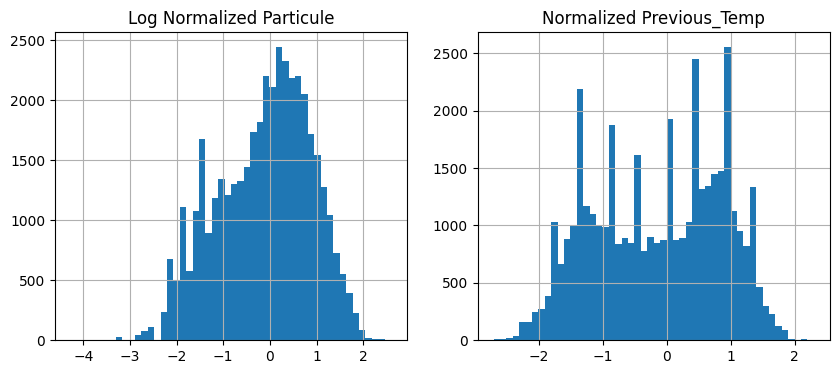

In [15]:
# Log
df["log_particule"] = df["Particule"].apply(lambda x: np.log1p(x))
df["log_previous_particule"] = df["Previous_Particule"].apply(lambda x: np.log1p(x))
df = df.drop(["Particule", "Previous_Particule"], axis = 1)

# Normalize
df["log_particule"] = (df["log_particule"] - df["log_particule"].median()) / df["log_particule"].std()
df["log_previous_particule"] = (df["log_previous_particule"] - df["log_previous_particule"].median()) / df["log_previous_particule"].std()
df["Previous_Temp"] = (df["Previous_Temp"] - df["Previous_Temp"].median()) / df["Previous_Temp"].std()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["log_particule"].hist(bins=50, ax=axes[0])
axes[0].set_title("Log Normalized Particule")

df["Previous_Temp"].hist(bins=50, ax=axes[1])
axes[1].set_title("Normalized Previous_Temp");

## Prediction

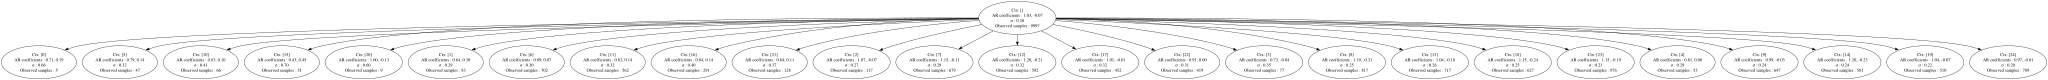

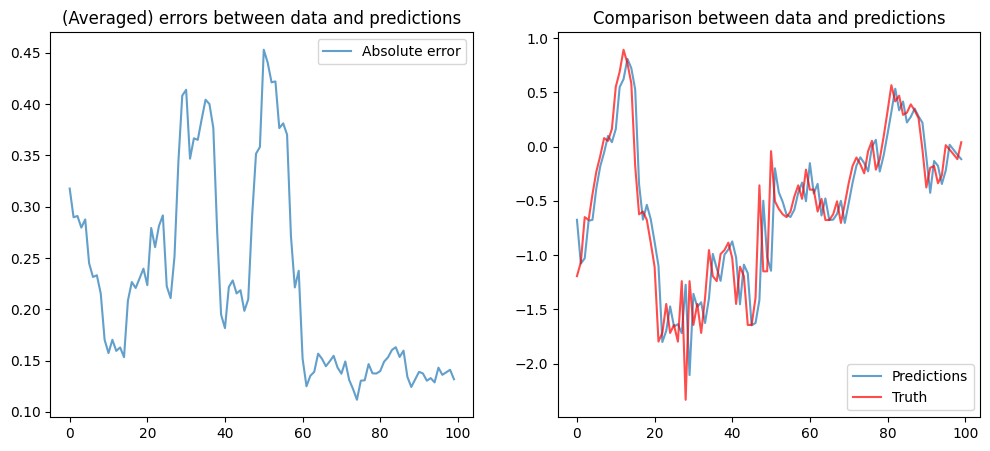

In [16]:
from ctw.models import BivariateQuantizer, BivariateARTree
from ctw.tree import view_tree

## Parameters
n_samples = 10_000
max_depth = 3
order = 2

seq_x = df["log_previous_particule"][:n_samples].tolist()
seq_y = df["Previous_Temp"][:n_samples].tolist()

nb_threshold = 5
thresholds = np.array([list(np.linspace(-2, 1.5, nb_threshold)), 
                             list(np.linspace(-2, 1.5, nb_threshold))])

bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq, beta = 0.5)

for x, y in zip(seq_x[:order], seq_y[:order]) :
    tree.observe(x, y)

# Draw error curve between predicted and actual values

predictions = []
actuals = []
for x_i, y_i in zip(seq_x[order:], seq_y[order:]):
    history = np.array([tree._x[-max_depth:], tree._y[-max_depth:]])
    prediction = tree.predict(history)
    predictions.append(prediction)
    actuals.append(x_i)
    tree.observe(x_i, y_i)
    
errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
window = 10  
error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')

data_to_plot = 100  # len(errors)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(error_avg[-data_to_plot:], label = "Absolute error", alpha = 0.7)
plt.legend()
plt.title("(Averaged) errors between data and predictions")

plt.subplot(1, 2, 2)
plt.plot(predictions[-data_to_plot:], label = "Predictions", alpha = 0.7)
plt.plot(actuals[-data_to_plot:], label = "Truth", alpha = 0.7, color = "red")
plt.legend()
plt.title("Comparison between data and predictions")

view_tree(tree.tree)